# 实验三：权重衰减与Dropout超参数调优
权重衰减系数 λ 与 Dropout 概率的手动调优及 Isolation 图分析


In [1]:
import torch
from torch import nn
from d2l import torch as d2l
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子以保证可重复性
torch.manual_seed(42)
np.random.seed(42)

print("环境配置完成")

环境配置完成


## 1. 数据加载与预处理
使用Fashion-MNIST数据集，并划分为训练集和验证集

In [2]:
# 加载完整训练集
batch_size = 256
train_iter_full, test_iter = d2l.load_data_fashion_mnist(batch_size)

# 将训练集划分为训练集和验证集 (80% / 20%)
# 获取所有训练数据
all_train_X = []
all_train_y = []
for X, y in train_iter_full:
    all_train_X.append(X)
    all_train_y.append(y)

all_train_X = torch.cat(all_train_X, dim=0)
all_train_y = torch.cat(all_train_y, dim=0)

print(f"总训练样本数: {len(all_train_y)}")

# 划分数据集
n_samples = len(all_train_y)
n_train = int(n_samples * 0.8)
n_val = n_samples - n_train

# 打乱顺序
indices = torch.randperm(n_samples)
train_indices = indices[:n_train]
val_indices = indices[n_train:]

# 创建训练集和验证集
train_X = all_train_X[train_indices]
train_y = all_train_y[train_indices]
val_X = all_train_X[val_indices]
val_y = all_train_y[val_indices]

# 创建DataLoader
train_dataset = torch.utils.data.TensorDataset(train_X, train_y)
val_dataset = torch.utils.data.TensorDataset(val_X, val_y)

train_iter = torch.utils.data.DataLoader(train_dataset, batch_size, shuffle=True)
val_iter = torch.utils.data.DataLoader(val_dataset, batch_size, shuffle=False)

print(f"训练集大小: {len(train_y)}")
print(f"验证集大小: {len(val_y)}")
print(f"测试集大小: {len(test_iter.dataset)}")

100.0%
100.0%
100.0%
100.0%


总训练样本数: 60000
训练集大小: 48000
验证集大小: 12000
测试集大小: 10000


## 2. 模型定义
定义MLP模型：784→256→128→10，激活函数为ReLU

In [3]:
# MLP模型定义：784 -> 256 -> 128 -> 10
class MLP(nn.Module):
    def __init__(self, num_inputs=784, num_hiddens1=256, num_hiddens2=128, num_outputs=10, dropout_p=0):
        super(MLP, self).__init__()
        self.layer1 = nn.Linear(num_inputs, num_hiddens1)
        self.layer2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.output = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_p)
        self.dropout_p = dropout_p
        
    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        x = self.relu(self.layer1(x))
        if self.dropout_p > 0:
            x = self.dropout(x)
        x = self.relu(self.layer2(x))
        if self.dropout_p > 0:
            x = self.dropout(x)
        return self.output(x)

def create_model(dropout_p=0):
    return MLP(dropout_p=dropout_p)

# 测试模型
test_model = create_model()
print(test_model)

MLP(
  (layer1): Linear(in_features=784, out_features=256, bias=True)
  (layer2): Linear(in_features=256, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0, inplace=False)
)


## 3. 训练和评估函数
定义训练和评估函数，支持权重衰减和Dropout

In [4]:
def train_and_evaluate(lr, weight_decay, dropout_p, num_epochs=20, verbose=False):
    """
    训练模型并返回结果
    
    参数：
        lr: 学习率
        weight_decay: 权重衰减系数
        dropout_p: Dropout概率
        num_epochs: 训练轮数
    
    返回：
        包含训练和验证结果的字典
    """
    # 创建模型
    model = create_model(dropout_p=dropout_p)
    
    # 定义损失函数和优化器
    loss = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # 记录最佳验证准确率
    best_val_acc = 0.0
    best_val_epoch = 0
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    
    for epoch in range(num_epochs):
        # 训练阶段
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for X, y in train_iter:
            optimizer.zero_grad()
            outputs = model(X)
            l = loss(outputs, y)
            l.backward()
            optimizer.step()
            
            train_loss += l.item() * X.size(0)
            _, predicted = outputs.max(1)
            train_total += y.size(0)
            train_correct += predicted.eq(y).sum().item()
        
        train_loss /= train_total
        train_acc = train_correct / train_total
        
        # 验证阶段
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for X, y in val_iter:
                outputs = model(X)
                l = loss(outputs, y)
                
                val_loss += l.item() * X.size(0)
                _, predicted = outputs.max(1)
                val_total += y.size(0)
                val_correct += predicted.eq(y).sum().item()
        
        val_loss /= val_total
        val_acc = val_correct / val_total
        
        # 记录历史
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # 更新最佳验证准确率
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_epoch = epoch + 1
        
        if verbose and (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{num_epochs}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")
    
    return {
        'lr': lr,
        'weight_decay': weight_decay,
        'dropout_p': dropout_p,
        'num_epochs': num_epochs,
        'final_train_loss': train_losses[-1],
        'final_train_acc': train_accs[-1],
        'best_val_acc': best_val_acc,
        'best_val_epoch': best_val_epoch,
        'final_val_loss': val_losses[-1],
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs
    }

print("训练和评估函数定义完成")

训练和评估函数定义完成


## 4. 任务A：权重衰减系数λ搜索
在不同学习率下测试不同的权重衰减系数，记录验证集性能

In [5]:
# 任务A：权重衰减搜索
print("="*60)
print("任务A：权重衰减系数λ搜索")
print("="*60)

# 超参数设置
learning_rates = [0.001, 0.01, 0.1]
weight_decays = [0, 1e-5, 1e-4, 1e-3, 1e-2]
num_epochs = 20

# 存储所有实验结果
results_weight_decay = []

# 遍历所有超参数组合
for lr in learning_rates:
    for wd in weight_decays:
        print(f"训练: lr={lr}, weight_decay={wd}")
        
        # 设置随机种子以保证公平性
        torch.manual_seed(42)
        np.random.seed(42)
        
        # 训练模型 (不使用Dropout)
        result = train_and_evaluate(lr=lr, weight_decay=wd, dropout_p=0, 
                                     num_epochs=num_epochs, verbose=True)
        results_weight_decay.append(result)
        
        print(f"  最终训练准确率: {result['final_train_acc']:.4f}")
        print(f"  最佳验证准确率: {result['best_val_acc']:.4f} (Epoch {result['best_val_epoch']})")

print("" + "="*60)
print("任务A实验完成!")
print("="*60)

任务A：权重衰减系数λ搜索
训练: lr=0.001, weight_decay=0
  Epoch 5/20: Train Acc=0.3469, Val Acc=0.3492
  Epoch 10/20: Train Acc=0.4231, Val Acc=0.4329
  Epoch 15/20: Train Acc=0.4987, Val Acc=0.5057
  Epoch 20/20: Train Acc=0.5794, Val Acc=0.5914
  最终训练准确率: 0.5794
  最佳验证准确率: 0.5914 (Epoch 20)
训练: lr=0.001, weight_decay=1e-05
  Epoch 5/20: Train Acc=0.3469, Val Acc=0.3491
  Epoch 10/20: Train Acc=0.4231, Val Acc=0.4329
  Epoch 15/20: Train Acc=0.4987, Val Acc=0.5057
  Epoch 20/20: Train Acc=0.5794, Val Acc=0.5914
  最终训练准确率: 0.5794
  最佳验证准确率: 0.5914 (Epoch 20)
训练: lr=0.001, weight_decay=0.0001
  Epoch 5/20: Train Acc=0.3468, Val Acc=0.3491
  Epoch 10/20: Train Acc=0.4230, Val Acc=0.4328
  Epoch 15/20: Train Acc=0.4986, Val Acc=0.5056
  Epoch 20/20: Train Acc=0.5792, Val Acc=0.5913
  最终训练准确率: 0.5792
  最佳验证准确率: 0.5913 (Epoch 20)
训练: lr=0.001, weight_decay=0.001
  Epoch 5/20: Train Acc=0.3469, Val Acc=0.3488
  Epoch 10/20: Train Acc=0.4225, Val Acc=0.4323
  Epoch 15/20: Train Acc=0.4983, Val Acc=0.5051


## 5. 任务B：Dropout概率搜索
在不同学习率下测试不同的Dropout概率，记录验证集性能

In [6]:
# 任务B：Dropout概率搜索
print("="*60)
print("任务B：Dropout概率搜索")
print("="*60)

# 超参数设置
learning_rates = [0.001, 0.01, 0.1]
dropout_probs = [0, 0.2, 0.4, 0.5, 0.7]
num_epochs = 20

# 存储所有实验结果
results_dropout = []

# 遍历所有超参数组合
for lr in learning_rates:
    for p in dropout_probs:
        print(f"训练: lr={lr}, dropout_p={p}")
        
        # 设置随机种子以保证公平性
        torch.manual_seed(42)
        np.random.seed(42)
        
        # 训练模型 (不使用权重衰减)
        result = train_and_evaluate(lr=lr, weight_decay=0, dropout_p=p, 
                                     num_epochs=num_epochs, verbose=True)
        results_dropout.append(result)
        
        print(f"  最终训练准确率: {result['final_train_acc']:.4f}")
        print(f"  最佳验证准确率: {result['best_val_acc']:.4f} (Epoch {result['best_val_epoch']})")

print("" + "="*60)
print("任务B实验完成!")
print("="*60)

任务B：Dropout概率搜索
训练: lr=0.001, dropout_p=0
  Epoch 5/20: Train Acc=0.3469, Val Acc=0.3492
  Epoch 10/20: Train Acc=0.4231, Val Acc=0.4329
  Epoch 15/20: Train Acc=0.4987, Val Acc=0.5057
  Epoch 20/20: Train Acc=0.5794, Val Acc=0.5914
  最终训练准确率: 0.5794
  最佳验证准确率: 0.5914 (Epoch 20)
训练: lr=0.001, dropout_p=0.2
  Epoch 5/20: Train Acc=0.2727, Val Acc=0.3474
  Epoch 10/20: Train Acc=0.3567, Val Acc=0.4112
  Epoch 15/20: Train Acc=0.4485, Val Acc=0.5196
  Epoch 20/20: Train Acc=0.5114, Val Acc=0.5886
  最终训练准确率: 0.5114
  最佳验证准确率: 0.5886 (Epoch 20)
训练: lr=0.001, dropout_p=0.4
  Epoch 5/20: Train Acc=0.2057, Val Acc=0.3479
  Epoch 10/20: Train Acc=0.2953, Val Acc=0.4037
  Epoch 15/20: Train Acc=0.3750, Val Acc=0.5060
  Epoch 20/20: Train Acc=0.4365, Val Acc=0.5430
  最终训练准确率: 0.4365
  最佳验证准确率: 0.5430 (Epoch 20)
训练: lr=0.001, dropout_p=0.5
  Epoch 5/20: Train Acc=0.1801, Val Acc=0.3473
  Epoch 10/20: Train Acc=0.2632, Val Acc=0.4052
  Epoch 15/20: Train Acc=0.3344, Val Acc=0.4995
  Epoch 20/20: Tr

KeyboardInterrupt: 

## 6. 结果可视化
绘制性能曲线和Isolation图

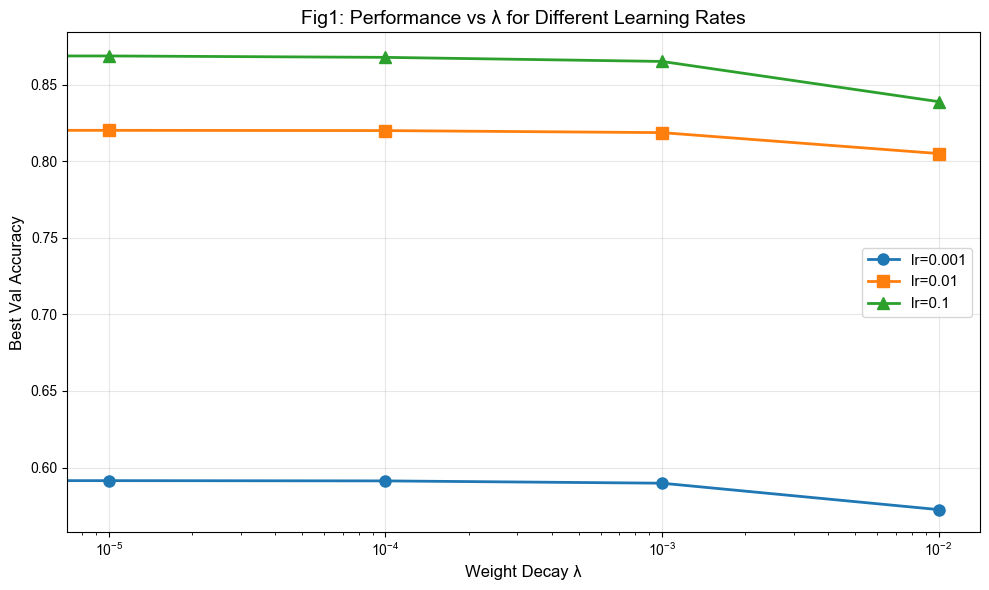

图1已保存: fig1_weight_decay_performance.png


In [ ]:
# ================ 图1：不同学习率下λ的性能曲线图 ================
fig1, ax1 = plt.subplots(figsize=(10, 6))

colors = {0.001: '#1f77b4', 0.01: '#ff7f0e', 0.1: '#2ca02c'}
markers = {0.001: 'o', 0.01: 's', 0.1: '^'}
labels = {0.001: 'lr=0.001', 0.01: 'lr=0.01', 0.1: 'lr=0.1'}

for lr in [0.001, 0.01, 0.1]:
    wds = []
    val_accs = []
    for result in results_weight_decay:
        if result["lr"] == lr:
            wds.append(result["weight_decay"])
            val_accs.append(result["best_val_acc"])
    
    sorted_pairs = sorted(zip(wds, val_accs))
    wds_sorted = [p[0] for p in sorted_pairs]
    val_accs_sorted = [p[1] for p in sorted_pairs]
    
    ax1.plot(wds_sorted, val_accs_sorted, 
             marker=markers[lr], color=colors[lr], label=labels[lr],
             linewidth=2, markersize=8)

ax1.set_xscale("log")
ax1.set_xlabel('Weight Decay λ', fontsize=12)
ax1.set_ylabel('Best Val Accuracy', fontsize=12)
ax1.set_title('Fig1: Performance vs λ for Different Learning Rates', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_weight_decay_performance.png', dpi=150)
plt.show()
print("图1已保存: fig1_weight_decay_performance.png")

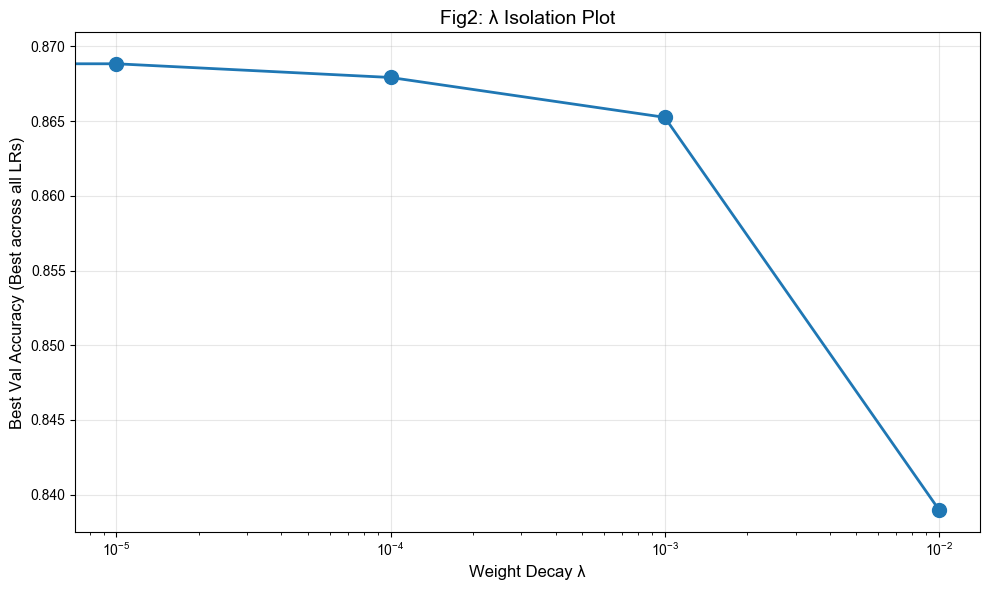

图2已保存: fig2_weight_decay_isolation.png


In [ ]:
# ================ 图2：λ的Isolation图 ================
fig2, ax2 = plt.subplots(figsize=(10, 6))

# 对于每个λ，取它在所有学习率中表现最好的验证准确率
weight_decay_values = [0, 1e-5, 1e-4, 1e-3, 1e-2]
isolation_vals = []

for wd in weight_decay_values:
    best_acc = 0
    for result in results_weight_decay:
        if result["weight_decay"] == wd:
            if result["best_val_acc"] > best_acc:
                best_acc = result["best_val_acc"]
    isolation_vals.append(best_acc)

ax2.plot(weight_decay_values, isolation_vals, 
         marker="o", color="#1f77b4", linewidth=2, markersize=10)
ax2.set_xscale("log")
ax2.set_xlabel('Weight Decay λ', fontsize=12)
ax2.set_ylabel('Best Val Accuracy (Best across all LRs)', fontsize=12)
ax2.set_title('Fig2: λ Isolation Plot', fontsize=14)
ax2.grid(True, alpha=0.3)

# 标注最佳点
best_idx = isolation_vals.index(max(isolation_vals))
ax2.annotate(f'Best: λ={weight_decay_values[best_idx]}', 
             xy=(weight_decay_values[best_idx], isolation_vals[best_idx]),
             xytext=(10, 10), textcoords="offset points",
             fontsize=11, arrowprops=dict(arrowstyle="->", color="red"))

plt.tight_layout()
plt.savefig('fig2_weight_decay_isolation.png', dpi=150)
plt.show()
print("图2已保存: fig2_weight_decay_isolation.png")

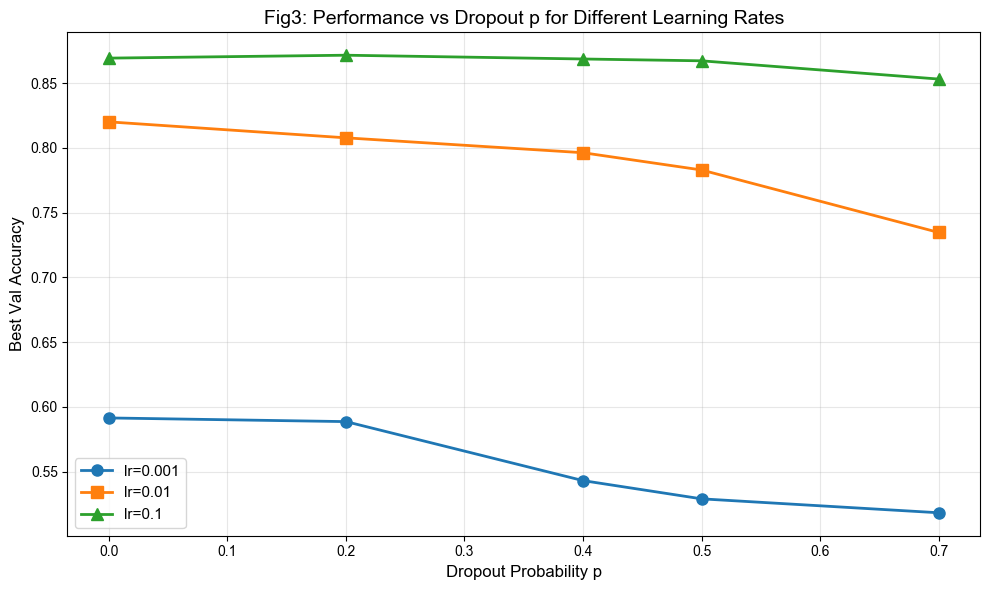

图3已保存: fig3_dropout_performance.png


In [ ]:
# ================ 图3：不同学习率下Dropout概率的性能曲线图 ================
fig3, ax3 = plt.subplots(figsize=(10, 6))

colors = {0.001: '#1f77b4', 0.01: '#ff7f0e', 0.1: '#2ca02c'}
markers = {0.001: 'o', 0.01: 's', 0.1: '^'}
labels = {0.001: 'lr=0.001', 0.01: 'lr=0.01', 0.1: 'lr=0.1'}

for lr in [0.001, 0.01, 0.1]:
    p_vals = []
    val_accs = []
    for result in results_dropout:
        if result["lr"] == lr:
            p_vals.append(result["dropout_p"])
            val_accs.append(result["best_val_acc"])
    
    sorted_pairs = sorted(zip(p_vals, val_accs))
    p_sorted = [p[0] for p in sorted_pairs]
    val_accs_sorted = [p[1] for p in sorted_pairs]
    
    ax3.plot(p_sorted, val_accs_sorted, 
             marker=markers[lr], color=colors[lr], label=labels[lr],
             linewidth=2, markersize=8)

ax3.set_xlabel('Dropout Probability p', fontsize=12)
ax3.set_ylabel('Best Val Accuracy', fontsize=12)
ax3.set_title('Fig3: Performance vs Dropout p for Different Learning Rates', fontsize=14)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_dropout_performance.png', dpi=150)
plt.show()
print("图3已保存: fig3_dropout_performance.png")

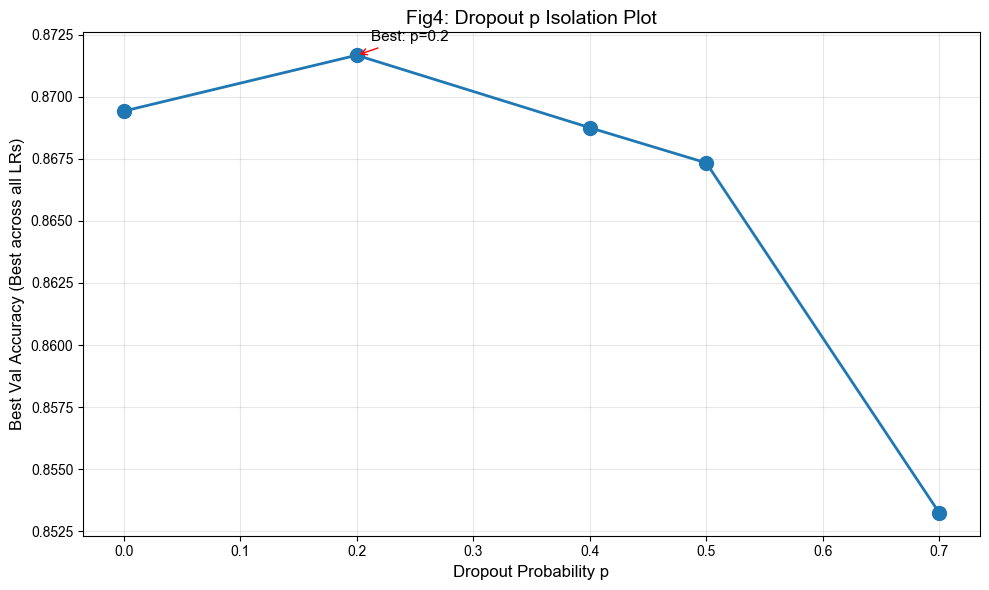

图4已保存: fig4_dropout_isolation.png


In [ ]:
# ================ 图4：Dropout概率的Isolation图 ================
fig4, ax4 = plt.subplots(figsize=(10, 6))

# 对于每个Dropout概率，取它在所有学习率中表现最好的验证准确率
dropout_values = [0, 0.2, 0.4, 0.5, 0.7]
isolation_vals = []

for p in dropout_values:
    best_acc = 0
    for result in results_dropout:
        if result["dropout_p"] == p:
            if result["best_val_acc"] > best_acc:
                best_acc = result["best_val_acc"]
    isolation_vals.append(best_acc)

ax4.plot(dropout_values, isolation_vals, 
         marker="o", color="#1f77b4", linewidth=2, markersize=10)
ax4.set_xlabel('Dropout Probability p', fontsize=12)
ax4.set_ylabel('Best Val Accuracy (Best across all LRs)', fontsize=12)
ax4.set_title('Fig4: Dropout p Isolation Plot', fontsize=14)
ax4.grid(True, alpha=0.3)

# 标注最佳点
best_idx = isolation_vals.index(max(isolation_vals))
ax4.annotate(f'Best: p={dropout_values[best_idx]}', 
             xy=(dropout_values[best_idx], isolation_vals[best_idx]),
             xytext=(10, 10), textcoords="offset points",
             fontsize=11, arrowprops=dict(arrowstyle="->", color="red"))

plt.tight_layout()
plt.savefig('fig4_dropout_isolation.png', dpi=150)
plt.show()
print("图4已保存: fig4_dropout_isolation.png")

In [ ]:
# ================ 保存实验结果到CSV ================
# 任务A：权重衰减结果
df_wd = pd.DataFrame([{
    'lr': r['lr'],
    'weight_decay': r['weight_decay'],
    'final_train_loss': r['final_train_loss'],
    'final_train_acc': r['final_train_acc'],
    'best_val_acc': r['best_val_acc'],
    'best_val_epoch': r['best_val_epoch'],
    'final_val_loss': r['final_val_loss']
} for r in results_weight_decay])

df_wd.to_csv('experimentA_weight_decay_results.csv', index=False)
print("任务A结果已保存: experimentA_weight_decay_results.csv")
print(df_wd)

# 任务B：Dropout结果
df_do = pd.DataFrame([{
    'lr': r['lr'],
    'dropout_p': r['dropout_p'],
    'final_train_loss': r['final_train_loss'],
    'final_train_acc': r['final_train_acc'],
    'best_val_acc': r['best_val_acc'],
    'best_val_epoch': r['best_val_epoch'],
    'final_val_loss': r['final_val_loss']
} for r in results_dropout])

df_do.to_csv('experimentB_dropout_results.csv', index=False)
print("\n任务B结果已保存: experimentB_dropout_results.csv")
print(df_do)

任务A结果已保存: experimentA_weight_decay_results.csv
       lr  weight_decay  final_train_loss  final_train_acc  best_val_acc  \
0   0.001       0.00000          1.464363         0.579375      0.591417   
1   0.001       0.00001          1.464405         0.579354      0.591417   
2   0.001       0.00010          1.464812         0.579167      0.591250   
3   0.001       0.00100          1.468869         0.577396      0.589750   
4   0.001       0.01000          1.509699         0.554333      0.572500   
5   0.010       0.00000          0.508332         0.826438      0.820167   
6   0.010       0.00001          0.508381         0.826438      0.820250   
7   0.010       0.00010          0.508858         0.826187      0.820083   
8   0.010       0.00100          0.513730         0.824875      0.818750   
9   0.010       0.01000          0.570777         0.809979      0.805083   
10  0.100       0.00000          0.297596         0.892042      0.869417   
11  0.100       0.00001          0.298139